## Nội dung

- Feature engineering
- Phân cụm: KMeans, DBSCAN
- Kết hợp phân cụm và phân tích mô tả
- Kết hợp PCA và phân cụm
- Tập dữ liệu:
   1. Customer Personality Analysis (nguồn: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)
   2. Taxi geolocation (nguồn: https://www.coursera.org/projects/clustering-geolocation-data-intelligently-python)

#### Cài đặt thư viện

In [118]:
%pip install folium
%pip install kneed
%pip install yellowbrick
%pip install kneed

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


### A. Customer Personality Analysis

#### A1. Đọc dữ liệu

In [119]:
import numpy as np
import pandas as pd

In [120]:
pd.set_option('display.max_columns', None)
customer_data = pd.read_csv('data/marketing_campaign.csv',
                           delimiter='\t', index_col='ID')
customer_data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


#### A2. Làm sạch
- Làm sạch dữ liệu.
- Trích xuất đặc trưng (đọc thêm: https://machinelearningcoban.com/general/2017/02/06/featureengineering/)

In [121]:
customer_data.info()

<class 'pandas.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   str    
 2   Marital_Status       2240 non-null   str    
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   str    
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int64  
 16  N

Dữ liệu khá sạch và chỉ có 1 số lượng nhỏ income bị thiếu dữ liệu, có thể xử lý bằng cách thêm vào mean. Mã hoá 1 số đặc trưng kiểu loại.

In [122]:
# TODO, Xử lý dữ liệu khuyết cho Income bằng cách thêm mean
customer_data['Income'] = customer_data['Income'].fillna(
    customer_data['Income'].mean()
)

print(customer_data['Income'].isnull().sum())

0


#### A3. Feature engineering

In [123]:
import datetime

Đầu tiên là dữ liệu liên quan ngày tháng.

- `Year_Birth` không phải là đặc trưng lý tưởng cho bài toán này, ta sẽ chuyển nó sang thành tuổi `Age` (tính từ hiện tại)

In [124]:
# Trích xuất tuổi từ đặc trưng năm sinh
# hint: 2022 - x
customer_data['Age'] = 2022 - customer_data['Year_Birth']

- `Days_Since_Customer`, tương tự như `Year_Birth`, nên được chuyển thành số ngày đã tham gia `Enroll_days`.

In [125]:
# Đặc trưng 'Days_Since_Customer' ~ ngày tham gia, biến đổi thành số lượng ngày đã tham gia

# Chuyển đổi ngày tháng theo định dạng DD-MM-YYYY
customer_data['Dt_Customer'] = pd.to_datetime(
    customer_data['Dt_Customer'],
    format='%d-%m-%Y'
)

# Lấy ngày hiện tại
now = datetime.datetime.now()

# Tính số ngày khách hàng đã tham gia
customer_data['Enroll_days'] = (
    now - customer_data['Dt_Customer']
).dt.days

customer_data[['Dt_Customer', 'Enroll_days']].head()

,Dt_Customer,Enroll_days
ID,,
5524,2012-09-04,5148
2174,2014-03-08,4598
4141,2013-08-21,4797
6182,2014-02-10,4624
5324,2014-01-19,4646


- Các đặc trưng `Marital_Status`, `Kidhome`, `Teenhome` có thể được gom lại 1 thuộc tính duy nhất --> cô động hơn

In [126]:
# Tạo ra đặc trưng Fam_size (số người trong gia đình)
# bằng cách gộp các đặc trưng: Martial_Status, Kidhome, Teenhome
marital_map = {
    'Absurd': 1, 'Alone': 1,
    'YOLO': 1, 'Single': 1,
    'Married': 2, 'Together': 2,
    'Widow': 1, 'Divorced': 1
} # married/together->2 người, khác-> 1 người
customer_data['Marital_Status'] = customer_data['Marital_Status'].map(marital_map)
customer_data['Fam_Size'] = (
    customer_data['Marital_Status']
    + customer_data['Kidhome']
    + customer_data['Teenhome']
)

- Gom các đặc trưng `AcceptedCmpX` thành 1 đặc trưng `Num_Accepted` (tổng)
- Làm tương tự cho các đặc trưng MntX, gom thành đặc trưng `MntTotal`

In [127]:
# Num_Accepted = AcceptedCmp1 + AcceptedCmp2 + ...
customer_data['Num_Accepted'] = customer_data[
    ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
     'AcceptedCmp4', 'AcceptedCmp5']
].sum(axis=1)


In [128]:
# Có thể gộp các đặc trưng MntXXX thành 1 thuộc tính duy nhất (tính tổng)
customer_data['MntTotal'] = customer_data[
    ['MntWines', 'MntFruits', 'MntMeatProducts',
     'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
].sum(axis=1)


#### A4. Phân tích EDA

In [129]:
customer_data.describe()

,Year_Birth,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,1.644643,52247.251354,0.444196,0.506250,2013-07-10 10:01:42.857142,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,53.194196,4838.582143,2.595089,0.297768,605.798214
min,1893.000000,1.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,26.000000,4485.000000,1.000000,0.000000,5.000000
25%,1959.000000,1.000000,35538.750000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,45.000000,4665.750000,2.000000,0.000000,68.750000
50%,1970.000000,2.000000,51741.500000,0.000000,0.000000,2013-07-08 12:00:00,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,52.000000,4840.500000,3.000000,0.000000,396.000000
75%,1977.000000,2.000000,68289.750000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,63.000000,5014.000000,3.000000,0.000000,1045.500000
max,1996.000000,2.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,129.000000,5184.000000,5.000000,4.000000,2525.000000
std,11.984069,0.478728,25037.797168,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,11.984069,202.122512,0.906959,0.678381,602.249288


In [130]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

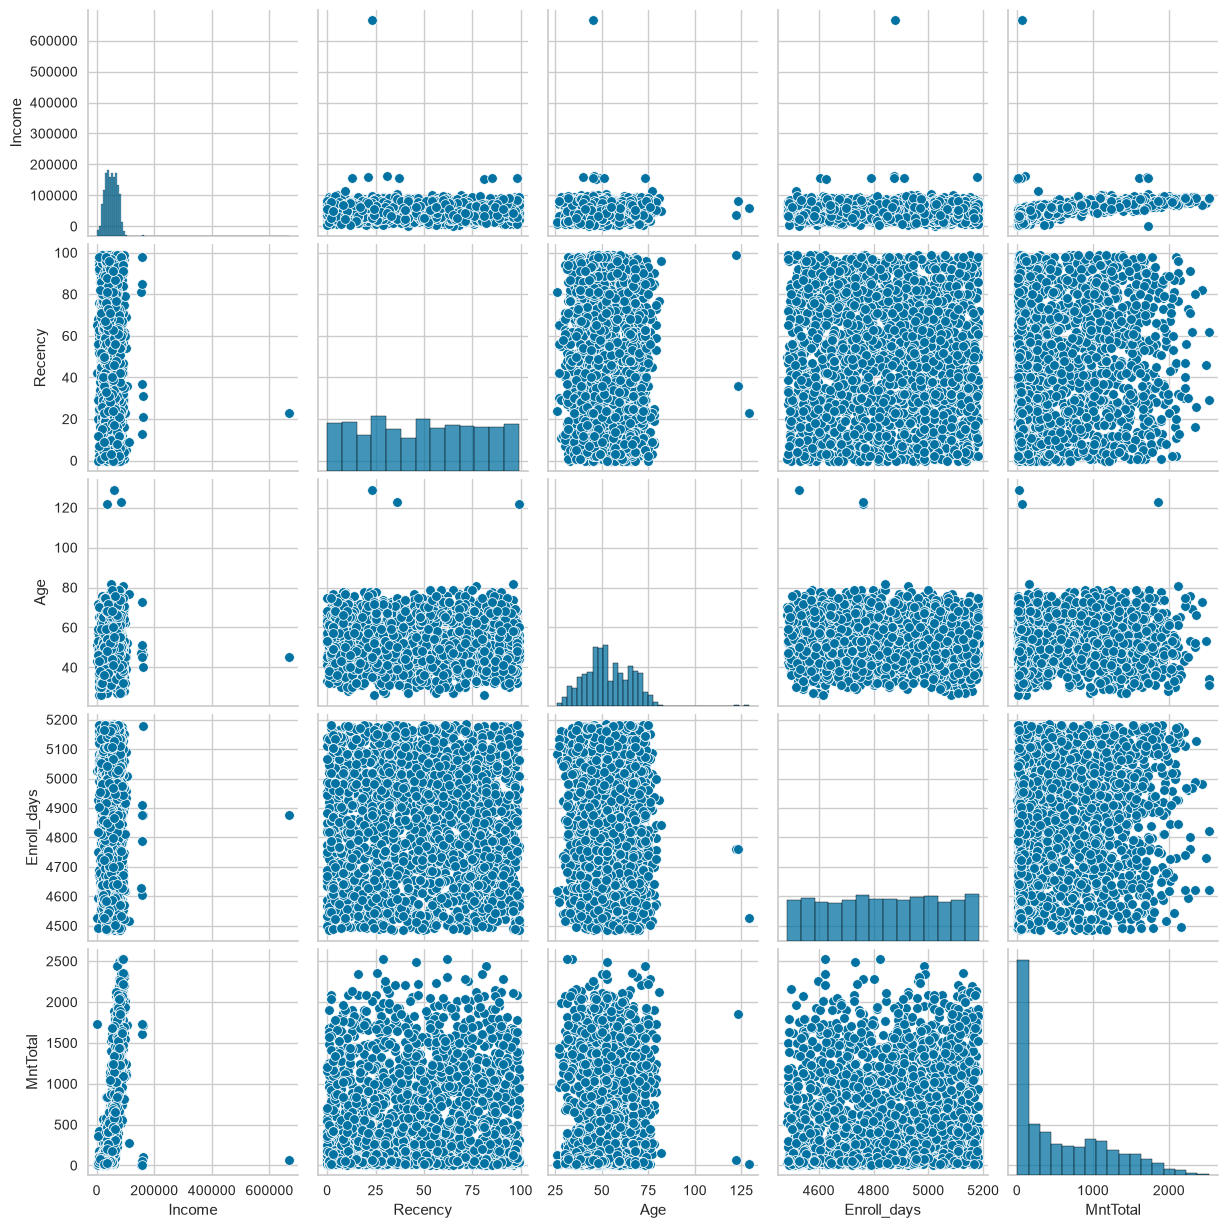

In [131]:
plot_cols = ['Income', 'Recency', 'Age', 'Enroll_days', 'MntTotal']
# TODO - vẽ pair plot
sns.pairplot(customer_data[plot_cols])
plt.show()

In [132]:
# TODO - xử lý nhiễu (nếu có)

# Kiểm tra giá trị bất thường
print(customer_data[['Age', 'Income']].describe())

# Loại bỏ các dòng có tuổi > 100
customer_data = customer_data[customer_data['Age'] <= 100].copy()

# Loại bỏ các dòng có Income vượt ngưỡng IQR
Q1 = customer_data['Income'].quantile(0.25)
Q3 = customer_data['Income'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

customer_data = customer_data[
    customer_data['Income'].between(lower, upper)
].copy()

print(customer_data.shape)


               Age         Income
count  2240.000000    2240.000000
mean     53.194196   52247.251354
std      11.984069   25037.797168
min      26.000000    1730.000000
25%      45.000000   35538.750000
50%      52.000000   51741.500000
75%      63.000000   68289.750000
max     129.000000  666666.000000
(2229, 33)


In [133]:
import copy
df = customer_data.copy()

# Drop các cột không quan trọng
df.drop([
    'Dt_Customer', 'Year_Birth',
    'Kidhome', 'Teenhome', 'Marital_Status',
    'Z_CostContact', 'Z_Revenue',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5',
    'Complain', 'Response', 'Education', 'Num_Accepted'
], axis=1, inplace=True)

#### A5. Tiền xử lý

**Mã hoá đặc trưng kiểu loại**

In [134]:
# TODO
from sklearn.preprocessing import LabelEncoder

cot_chu = df.select_dtypes(include=['object', 'category']).columns

for col in cot_chu:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

print(df.dtypes)

Income                 float64
Recency                  int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
Age                      int64
Enroll_days              int64
Fam_Size                 int64
MntTotal                 int64
dtype: object


**Chuẩn hoá các thuộc tính kiểu số**

In [135]:
# TODO
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[df.columns] = scaler.fit_transform(df)

df.head()


,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Enroll_days,Fam_Size,MntTotal
ID,,,,,,,,,,,
5524,0.316030,0.307314,0.358938,1.405471,2.633984,-0.559160,0.689920,1.015715,1.529265,-1.759459,1.683247
2174,-0.256586,-0.383771,-0.168815,-1.117198,-0.585437,-1.176175,-0.138430,1.272020,-1.190769,0.445057,-0.962795
4141,0.970262,-0.798422,-0.696567,1.405471,-0.227723,1.291882,-0.552605,0.332234,-0.206611,-0.657201,0.283674
6182,-1.212954,-0.798422,-0.168815,-0.756817,-0.943150,-0.559160,0.275745,-1.291031,-1.062186,0.445057,-0.919526
5324,0.323556,1.551268,1.414444,0.324327,0.129990,0.057854,-0.138430,-1.034726,-0.953384,0.445057,-0.305445


In [136]:
df.describe() # --> Kiểm tra mean và std có gần với giá trị (0, 1)?

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Enroll_days,Fam_Size,MntTotal
count,2.229000e+03,2.229000e+03,2.229000e+03,2.229000e+03,2.229000e+03,2.229000e+03,2.229000e+03,2.229000e+03,2.229000e+03,2.229000e+03,2.229000e+03
mean,2.231404e-17,-6.694212e-17,-9.244387e-17,-7.331755e-17,5.100352e-17,-6.176207e-17,-9.563159e-18,2.151711e-16,5.387246e-16,9.563159e-17,1.115702e-17
std,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00,1.000224e+00
min,-2.422663e+00,-1.696833e+00,-1.224320e+00,-1.477580e+00,-9.431503e-01,-1.793189e+00,-2.209304e+00,-2.316251e+00,-1.749613e+00,-1.759459e+00,-9.994070e-01
25%,-7.871572e-01,-8.675308e-01,-6.965674e-01,-7.568171e-01,-9.431503e-01,-8.676676e-01,-9.667794e-01,-6.929856e-01,-8.544740e-01,-6.572011e-01,-8.928996e-01
50%,-3.195949e-03,-3.674007e-03,-1.688146e-01,-3.605431e-02,-2.277234e-01,-2.506534e-01,2.757449e-01,-9.494056e-02,1.099152e-02,4.450572e-01,-3.470494e-01
75%,8.005743e-01,8.601828e-01,3.589382e-01,6.847085e-01,4.877036e-01,6.748679e-01,6.899196e-01,8.448445e-01,8.665660e-01,4.450572e-01,7.296736e-01
max,3.015300e+00,1.724040e+00,6.691972e+00,8.252718e+00,9.072827e+00,2.217403e+00,6.074192e+00,2.468110e+00,1.707304e+00,2.649574e+00,3.194321e+00


#### A6. Phân cụm KMeans

In [137]:
from sklearn.cluster import KMeans

Phương pháp Elbow: ước lượng số cụm

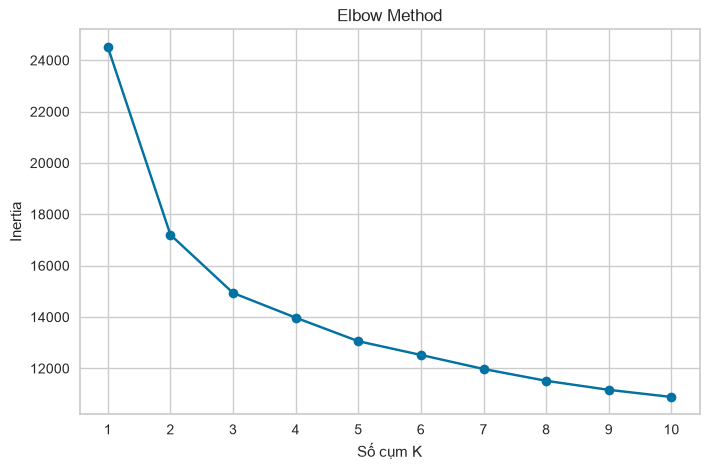

In [138]:
# TODO - vẽ biểu đồ elbow để ước lượng số cụm
from sklearn.cluster import KMeans

inertias = []
K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, n_init=20, random_state=99)
    model.fit(df)
    inertias.append(model.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Số cụm K')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.xticks(K_range)
plt.grid(True)
plt.show()


Sử dụng thư viện yellowbrick

In [139]:
%pip install --upgrade setuptools yellowbrick

Note: you may need to restart the kernel to use updated packages.


In [140]:
from yellowbrick.cluster import KElbowVisualizer

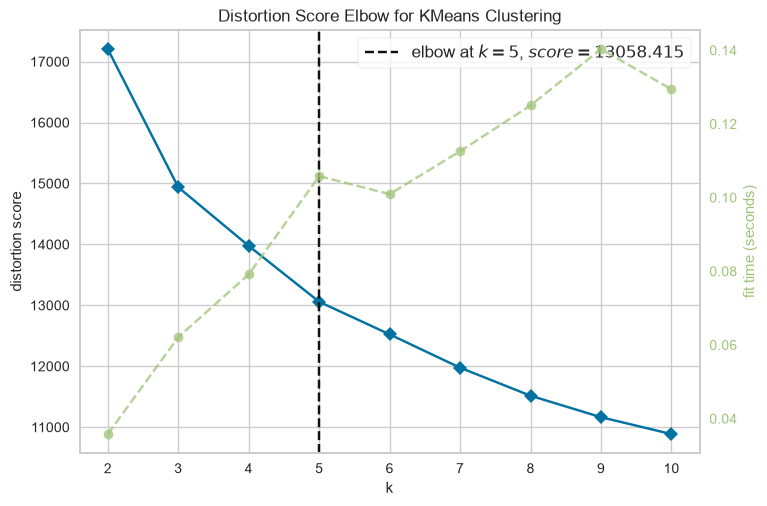

K tối ưu: 5


In [141]:
# TODO
from sklearn.cluster import KMeans

model = KMeans(n_init=20, random_state=99)

visualizer = KElbowVisualizer(
    model,
    k=(2, 11),
    force_model=True
)

visualizer.fit(df)
visualizer.show()

print("K tối ưu:", visualizer.elbow_value_)


**Phân cụm từ kết quả của phương pháp Elbow**

In [142]:
# TODO
K = visualizer.elbow_value_

kmean = KMeans(n_clusters=K, n_init=20, random_state=99)

labels = kmean.fit_predict(df)

print("Số cụm:", K)
print("Nhãn phân cụm:", labels)
print("Số khách hàng mỗi cụm:")
print(np.unique(labels, return_counts=True))

Số cụm: 5
Nhãn phân cụm: [2 0 2 ... 4 2 0]
Số khách hàng mỗi cụm:
(array([0, 1, 2, 3, 4], dtype=int32), array([493, 236, 493, 552, 455]))


**Sử dụng PCA giảm số chiều dữ liệu --> trực quan hoá kết quả phân cụm**

In [143]:
from sklearn.decomposition import PCA

In [144]:
# Biến đổi dữ liệu sang không gian 2 chiều pca
# TODO
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2)

scores = pca_2d.fit_transform(df)

print(scores.shape)
print("Tỷ lệ phương sai giữ lại:",
      pca_2d.explained_variance_ratio_.sum())

(2229, 2)
Tỷ lệ phương sai giữ lại: 0.5351985782400119


**Trực quan hoá kết quả phân cụm**

In [145]:
def visualize_cluster_result(scores, labels):
    '''
    Args:
        scores: biến đổi pca 2d
        labels: nhãn của từng điểm dữ liệu trong scores (chính là label của kết quả phân cụm)
    '''
    # TODO
    visualize_cluster_result(scores, kmean.labels_)
    fig1, (axes) = plt.subplots(figsize=(8,8))
    scat_1 = sns.scatterplot(
                            x=scores[:,0],
                            y=scores[:,1],
                            hue=labels, ax=axes,
                            palette='Set1', legend='full'
            )
    plt.show()

#### Phân tích kết quả phân cụm (KMeans)

In [146]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_df = customer_data.copy()
kmean_df['Cluster'] = kmean.labels_
kmean_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,1,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,65,5148,1,0,1617,2
2174,1954,Graduation,1,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,68,4598,3,0,27,0
4141,1965,Graduation,2,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,57,4797,2,0,776,2
6182,1984,Graduation,2,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,38,4624,3,0,53,3
5324,1981,PhD,2,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,41,4646,3,0,422,1


In [147]:
def visualize_cluster_distribution(labels):
    '''
    Args:
        labels: kết quả phân cụm (danh sách nhãn)
    '''
    ulabels, count = np.unique(labels, return_counts=True)
    plt.figure(figsize=(6,4))

    colors = sns.color_palette('Set2')[0:5]
    
    labels = [f'Cluster {i+1}' for i in range(len(ulabels))]
    plt.pie(count, 
            explode=[0.05]*len(ulabels), 
            labels=labels,
            colors=colors,
            autopct='%1.1f%%',
            textprops=dict(color ="white", fontsize=10),
            counterclock=False,
            startangle=180,
            wedgeprops={"edgecolor":"gray",'linewidth': 1}
        )

    plt.axis('equal')
    plt.legend()
    plt.show()

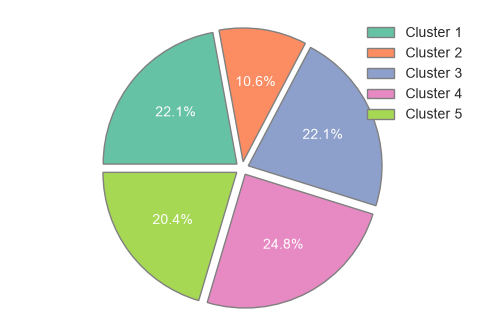

In [148]:
visualize_cluster_distribution(kmean.labels_)

**Phân tích đa biến + kết quả phân cụm**

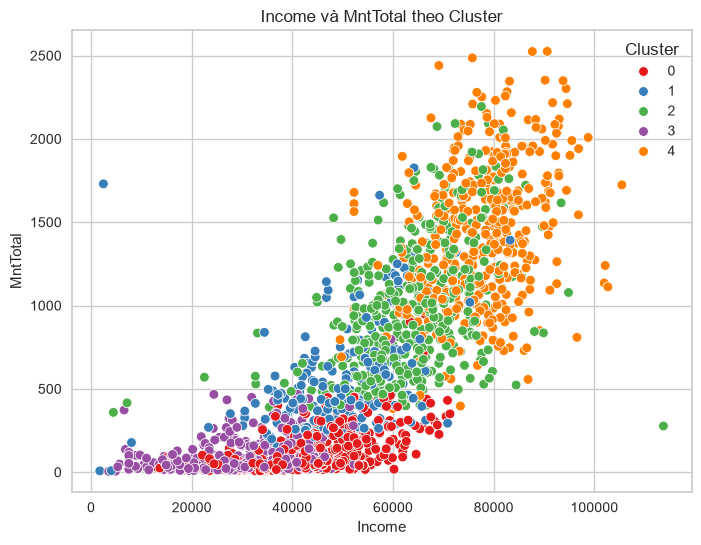

In [149]:
# đặc trưng income và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=kmean_df,
    x='Income',
    y='MntTotal',
    hue='Cluster',
    palette='Set1'
)

plt.title('Income và MntTotal theo Cluster')
plt.grid(True)
plt.show()

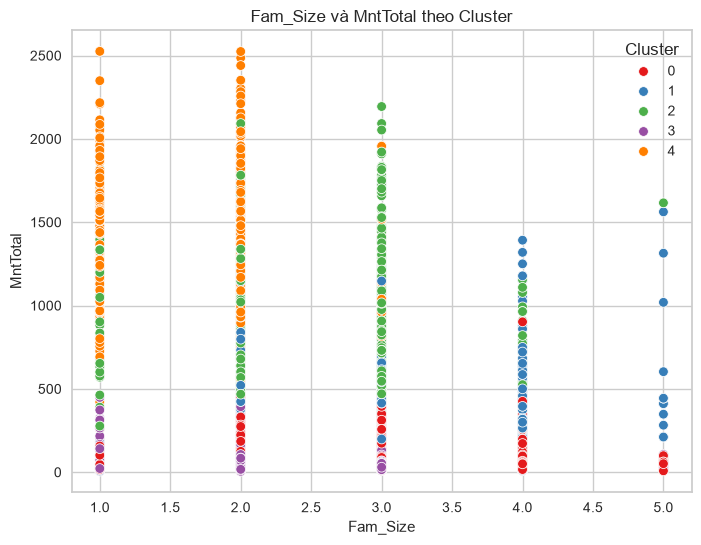

In [150]:
# đặc trưng Fam_Size và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=kmean_df,
    x='Fam_Size',
    y='MntTotal',
    hue='Cluster',
    palette='Set1'
)

plt.title('Fam_Size và MntTotal theo Cluster')
plt.grid(True)
plt.show()

**Phân tích danh mục mua hàng**

,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Cluster,,,,,,
0,67.906694,5.194726,27.273834,7.135903,5.344828,15.634888
1,313.991525,15.550847,109.940678,24.012712,16.313559,53.296610
2,550.342799,39.350913,193.567951,52.691684,41.401623,69.141988
3,29.434783,6.014493,22.483696,9.094203,5.911232,17.461957
4,625.668132,65.450549,486.123077,96.094505,66.778022,75.419780


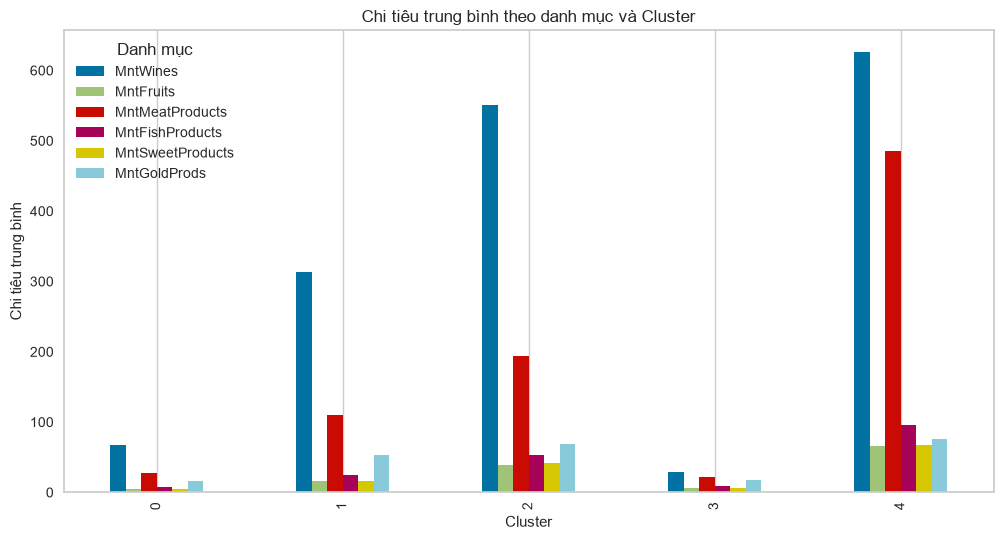

In [151]:
# TODO
cot_mua_hang = [
    'MntWines',
    'MntFruits',
    'MntMeatProducts',
    'MntFishProducts',
    'MntSweetProducts',
    'MntGoldProds'
]

# Chi tiêu trung bình theo cụm
bang = kmean_df.groupby('Cluster')[cot_mua_hang].mean()

display(bang)

# Vẽ biểu đồ
bang.plot(kind='bar', figsize=(12, 6))
plt.title('Chi tiêu trung bình theo danh mục và Cluster')
plt.xlabel('Cluster')
plt.ylabel('Chi tiêu trung bình')
plt.legend(title='Danh mục')
plt.grid(axis='y')
plt.show()

#### A7. Kết hợp PCA và phân cụm
- Biến đổi PCA với số lượng component phù hợp (giữ lại 70-80% thông tin ban đầu).
- Ước lượng số cụm dùng elbow (dùng dữ liệu pca).
- Với số cụm phù hợp, thực hiện phân cụm trên dữ liệu pca.
- Vẽ phân bố kết quả phân cụm.
- Vẽ biểu đồ scatter MntTotal-Income-Cluster.

In [152]:
# vẽ biểu đồ sreeplot
def scree_plot(pca_model, xlabels):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # explained variance ratio của mô hình pca
    expl_var_ratio = pca_model.explained_variance_ratio_
    # tính cumulative sum của expl_var_ratio (numpy.cumsum)
    expl_var_cumsum = np.cumsum(expl_var_ratio)
    xtick_indx = range(1, len(expl_var_ratio) + 1)
    
    # vẽ các bar thể hiện explained_var
    ax.bar(xtick_indx, expl_var_ratio)
    ax.plot(xtick_indx, expl_var_cumsum, marker='o', color='k')
    
    # set label
    ax.set_xticks(xtick_indx)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel('Principle Components')
    ax.set_ylabel('% variance')
    ax.set_title('Scree Plot')
    
    plt.grid(True)

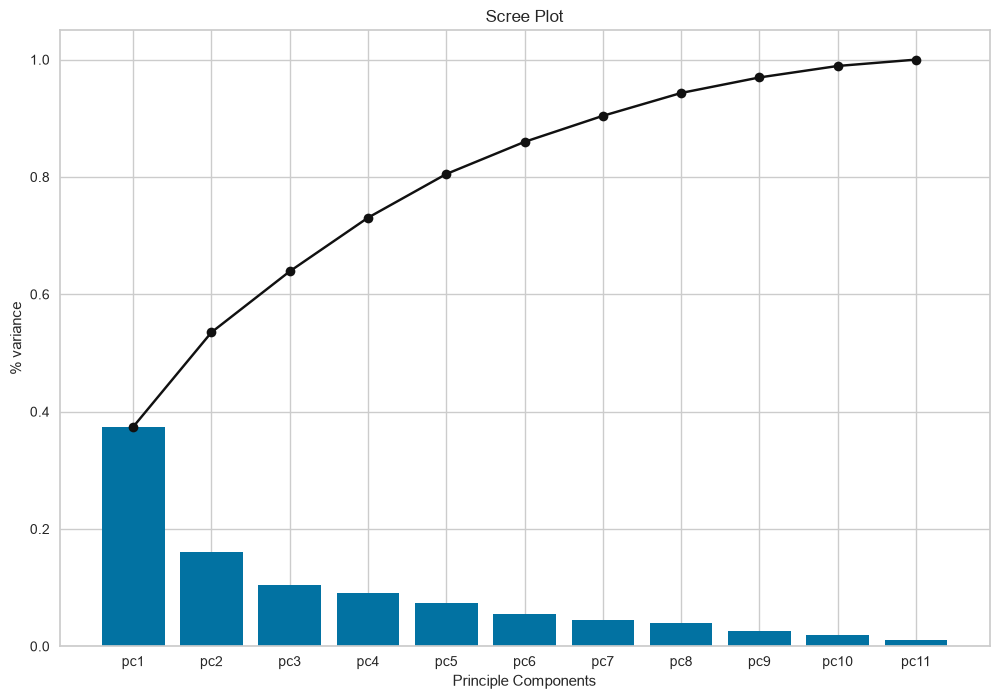

In [153]:
pca = PCA()
pca.fit(df)

scree_plot(
    pca,
    [f'pc{i+1}' for i in range(len(df.columns))]
)

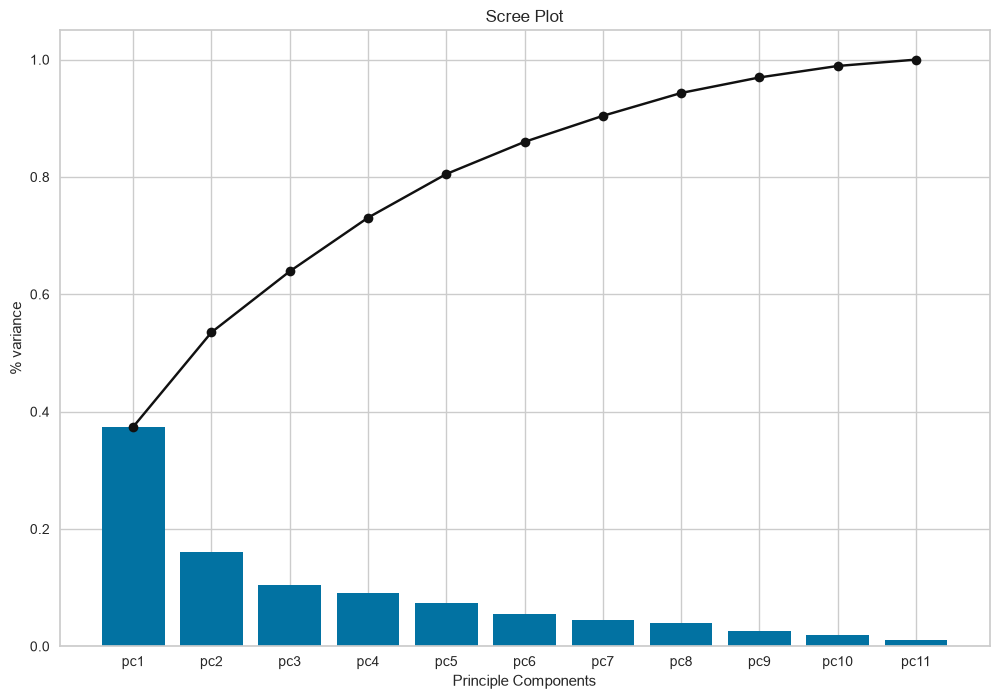

In [154]:
scree_plot(pca, [f'pc{i+1}' for i in range(len(df.columns))])

In [155]:
# biến đổi df sang không gian pca 4 chiều
# TODO
pca_4d = PCA(n_components=4)

pca_transformed_4d = pca_4d.fit_transform(df)

print(pca_transformed_4d.shape)
print("Phương sai giữ lại:",
      pca_4d.explained_variance_ratio_.sum())

(2229, 4)
Phương sai giữ lại: 0.7305942032273587


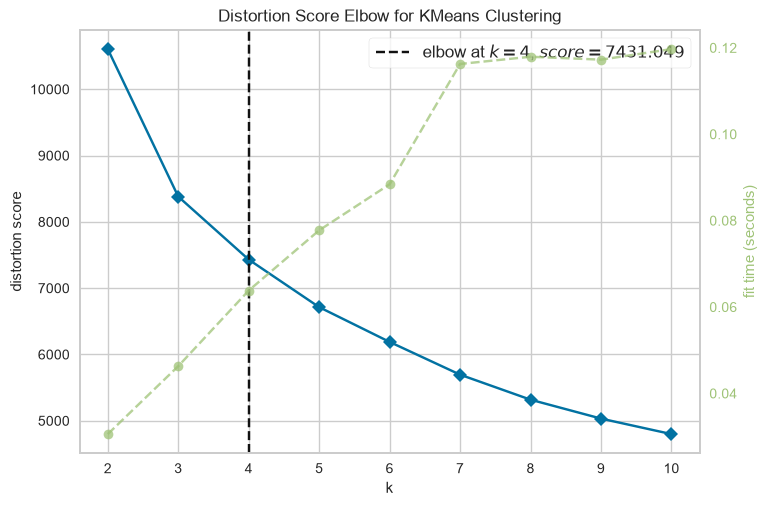

K tối ưu: 4


In [156]:
model = KMeans(n_init=20, random_state=99)

visualizer = KElbowVisualizer(
    model,
    k=10,
    force_model=True
)

visualizer.fit(pca_transformed_4d)
visualizer.show()

print("K tối ưu:", visualizer.elbow_value_)

In [157]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_pca_df = customer_data.copy()
kmean_pca_df['Cluster'] = kmean.labels_
kmean_pca_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,1,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,65,5148,1,0,1617,2
2174,1954,Graduation,1,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,68,4598,3,0,27,0
4141,1965,Graduation,2,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,57,4797,2,0,776,2
6182,1984,Graduation,2,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,38,4624,3,0,53,3
5324,1981,PhD,2,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,41,4646,3,0,422,1


In [158]:
K_pca = visualizer.elbow_value_

kmean_pca = KMeans(
    n_clusters=K_pca,
    n_init=20,
    random_state=99
)

labels_pca = kmean_pca.fit_predict(pca_transformed_4d)

kmean_pca_df = customer_data.copy()
kmean_pca_df['Cluster'] = labels_pca

kmean_pca_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,1,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,65,5148,1,0,1617,1
2174,1954,Graduation,1,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,68,4598,3,0,27,3
4141,1965,Graduation,2,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,57,4797,2,0,776,1
6182,1984,Graduation,2,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,38,4624,3,0,53,2
5324,1981,PhD,2,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,41,4646,3,0,422,0


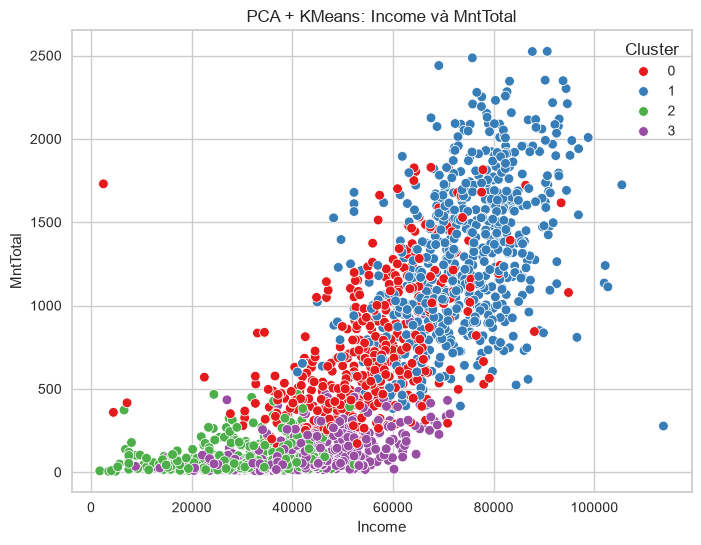

In [159]:
# đặc trưng income và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=kmean_pca_df,
    x='Income',
    y='MntTotal',
    hue='Cluster',
    palette='Set1'
)

plt.title('PCA + KMeans: Income và MntTotal')
plt.grid(True)
plt.show()

#### A9. Phân tích kết quả phân cụm (DBSCAN)

In [160]:
from sklearn.cluster import DBSCAN

**Sử dụng knee plot để ước lượng eps**

In [161]:
len(df.columns)

11

In [162]:
from sklearn.neighbors import NearestNeighbors
def knee_plot(n_neighs, data):
    neigh = NearestNeighbors(n_neighbors=n_neighs)
    nbrs = neigh.fit(data)
    distances, indices = nbrs.kneighbors(data)

    # plot
    distances = np.sort(distances, axis=0)
    distances = distances[:,-1]
    plt.plot(distances)
    
    return distances

**Sử dụng PCA thu giảm số chiều --> phân cụm**

**Chia nhỏ đặc trưng**

In [163]:
sub_df = df[['Income', 'MntTotal', 'Enroll_days']]

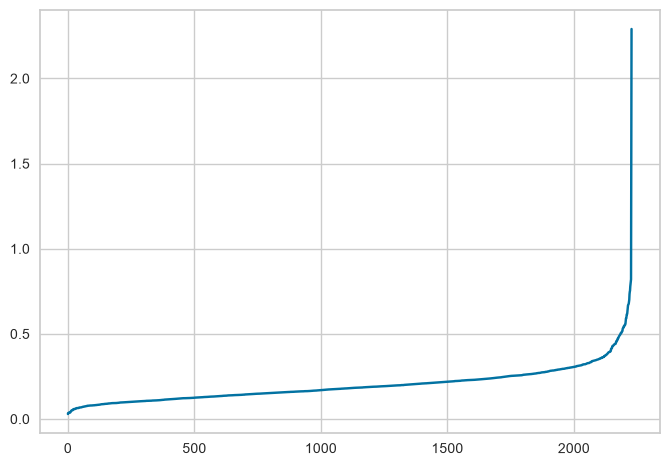

In [164]:
# Dữ liệu đã chuẩn hóa từ A5
X_dbscan = sub_df.to_numpy()

# Vẽ k-distance để chọn eps
knee_plot(5, X_dbscan)
plt.show()

In [165]:
eps = 0.5  # Điều chỉnh dựa trên k-distance

dbscan = DBSCAN(eps=eps, min_samples=5)
labels_dbscan = dbscan.fit_predict(X_dbscan)

print("Số cụm:", len(set(labels_dbscan) - {-1}))
print("Số nhiễu:", np.sum(labels_dbscan == -1))


Số cụm: 1
Số nhiễu: 22


### B. Dữ liệu taxi 

In [166]:
import pandas as pd

In [167]:
df = pd.read_csv('data/taxi_data.csv')
df.head()

,LON,LAT,NAME
0,28.17858,-25.73882,11th Street Taxi Rank
1,28.17660,-25.73795,81 Bazaar Street Taxi Rank
2,27.83239,-26.53722,Adams Road Taxi Rank
3,28.12514,-26.26666,Alberton City Mall Taxi Rank
4,28.10144,-26.10567,Alexandra Main Taxi Rank


**Biểu diễn giá trị toạ độ trên bản đồ**

In [168]:
import folium, re

In [171]:
# Kiểm tra giá trị thiếu
print(df[['LAT', 'LON']].isnull().sum())

# Loại bỏ các dòng thiếu tọa độ
df = df.dropna(subset=['LAT', 'LON']).copy()

# Lấy lại tọa độ sau khi làm sạch
X = df[['LAT', 'LON']].values

# Tạo bản đồ
m = folium.Map(
    location=[X[:, 0].mean(), X[:, 1].mean()],
    tiles='OpenStreetMap',
    zoom_start=10
)

m

LAT    0
LON    0
dtype: int64


In [172]:
for _,row in df.iterrows():
    folium.CircleMarker(
        location=[row.LAT,row.LON],
        radius=5,
        popup=re.sub(r'\W+',' ',row.NAME),
        fill=True
    ).add_to(m)

# Loại bỏ non-word chars
title = '''<h3 align="center" style="font-size:30px"><b>Given Data</b></h3>'''
m.get_root().html.add_child(folium.Element(title))
m

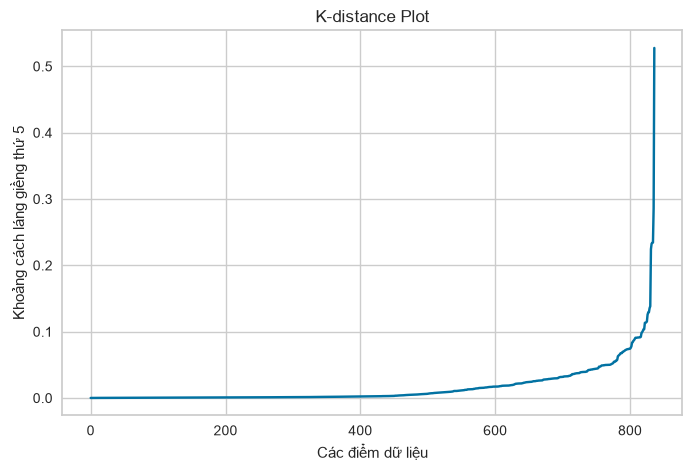

In [173]:
# Knee plot để ước lượng eps
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors.fit(X)

distances, indices = neighbors.kneighbors(X)

distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.xlabel('Các điểm dữ liệu')
plt.ylabel('Khoảng cách láng giềng thứ 5')
plt.title('K-distance Plot')
plt.grid(True)
plt.show()


In [174]:
#First create an array of color schemes
colors = ['royalblue', 'maroon', 'forestgreen', 'mediumorchid', 'tan', 'deeppink', 
          'olive', 'goldenrod', 'lightcyan', 'navy','springgreen','midnightblue',
         'red','brown','limegreen','lime','pink','orchid','crimson','m']*10

In [175]:
# Sử dụng DBSCAN để phân cụm
from sklearn.cluster import DBSCAN

eps = 0.02  # Giá trị thử nghiệm
min_samples = 5

dbscan = DBSCAN(eps=eps, min_samples=min_samples)
labels = dbscan.fit_predict(X)

df['Cluster'] = labels

# Gán màu theo cụm
df['Color'] = [
    'black' if label == -1 else colors[label % len(colors)]
    for label in labels
]

print("Số cụm:", len(set(labels) - {-1}))
print("Số điểm nhiễu:", np.sum(labels == -1))

Số cụm: 51
Số điểm nhiễu: 181


In [178]:
def create_map(cluster_column, colors_column, title):
    m = folium.Map(
        location=[X[:, 0].mean(), X[:, 1].mean()],
        tiles='OpenStreetMap',
        zoom_start=8.5
    )

    for _, row in df.iterrows():
        folium.CircleMarker(
            location=[row.LAT, row.LON],
            radius=5,
            popup=str(row[cluster_column]),
            fill=True,
            color=row[colors_column],
            fill_color=row[colors_column]
        ).add_to(m)

    print(title)
    return m

In [179]:
m_cluster = create_map(
    cluster_column='Cluster',
    colors_column='Color',
    title='DBSCAN Taxi Clustering'
)

m_cluster

DBSCAN Taxi Clustering
